# CNN Train and Evaluation Experiments

This notebook is the complete CNN experiment runner for the `CNN-Full-Experiment` branch.

It runs and records these experiments with MLflow:

1. ResNet18 without pretraining + weighted BCE
2. ResNet18 without pretraining + focal loss
3. DenseNet121 + weighted BCE + no ImageNet pretraining
4. DenseNet121 + weighted BCE + ImageNet pretraining
5. DenseNet121 + focal loss + ImageNet pretraining

The training script automatically saves the best validation mean-AUROC checkpoint and evaluates it on the test set. Results are saved under `artifacts/metrics/` and logged to MLflow.


## 0. Setup

This notebook can be opened from `visiontrans_diagnostics/` or `visiontrans_diagnostics/notebooks/`. It changes directory to the git repo root before running commands.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys
import time

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "run_experiment.py").exists() and (REPO_ROOT.parent / "src" / "run_experiment.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "run_experiment.py").exists():
    raise RuntimeError(f"Could not resolve repo root from {Path.cwd()}")

os.chdir(REPO_ROOT)
print("Repo root:", REPO_ROOT)
print("Python:", sys.executable)


Repo root: /root/visiontrans_diagnostics
Python: /root/miniconda3/bin/python


In [2]:
def run_command(cmd, cwd=REPO_ROOT, env=None):
    print("$", " ".join(str(part) for part in cmd))
    start = time.time()
    process = subprocess.Popen(
        [str(part) for part in cmd],
        cwd=str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )
    lines = []
    for line in process.stdout:
        print(line, end="")
        lines.append(line)
    code = process.wait()
    elapsed = time.time() - start
    print(f"\n[exit_code={code}] elapsed={elapsed/60:.2f} min")
    if code != 0:
        raise RuntimeError(f"Command failed with exit code {code}")
    return "".join(lines)


## 1. Environment and MLflow Check

In [3]:
import torch

REQUIRE_ACCELERATOR = True

def resolve_notebook_device(require_accelerator=True):
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if require_accelerator:
        raise RuntimeError("This notebook requires CUDA on AutoDL or MPS on MacBook. No accelerator is available.")
    return torch.device("cpu")

NOTEBOOK_DEVICE = resolve_notebook_device(require_accelerator=REQUIRE_ACCELERATOR)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("mps available:", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("cuda:", torch.version.cuda)
    print("gpu:", torch.cuda.get_device_name(0))
print("selected device:", NOTEBOOK_DEVICE)

try:
    import mlflow
    print("mlflow:", mlflow.__version__)
except Exception as exc:
    print("MLflow import failed:", exc)



libgomp: Invalid value for environment variable OMP_NUM_THREADS


torch: 2.5.1+cu124
cuda available: True
mps available: False
cuda: 12.4
gpu: NVIDIA GeForce RTX 4090
selected device: cuda
mlflow: 3.11.1


In [4]:
from src.config import load_config

base_config = load_config("configs/base.yaml")
print("MLflow tracking URI:", base_config["mlflow"]["tracking_uri"])
print("MLflow experiment:", base_config["mlflow"]["experiment_name"])
print("MLflow artifact location:", base_config["mlflow"].get("artifact_location"))


MLflow tracking URI: sqlite:///mlflow.db
MLflow experiment: cnn_vs_vit_medical
MLflow artifact location: mlruns


## 2. Experiment Plan

All runs use the same split, data pipeline, test evaluator, and MLflow experiment. For comparability, BCE here means `BCEWithLogitsLoss(pos_weight=...)`, matching the class-imbalance setup used in the DenseNet baseline.


In [5]:
EXPERIMENTS = [
    {
        "key": "resnet18_bce",
        "label": "ResNet18 no pretrain + weighted BCE",
        "config": "configs/cnn_resnet18_bce.yaml",
        "run_name": "resnet18_bce",
    },
    {
        "key": "resnet18_focal",
        "label": "ResNet18 no pretrain + focal",
        "config": "configs/cnn_resnet18_focal.yaml",
        "run_name": "resnet18_focal",
    },
    {
        "key": "densenet121_no_pretrain_bce",
        "label": "DenseNet121 no pretrain + weighted BCE",
        "config": "configs/cnn_densenet121_no_pretrain_bce.yaml",
        "run_name": "densenet121_no_pretrain_bce",
    },
    {
        "key": "densenet121_pretrained_bce",
        "label": "DenseNet121 pretrained + weighted BCE",
        "config": "configs/cnn_densenet121_pretrained_bce.yaml",
        "run_name": "densenet121_pretrained_bce",
    },
    {
        "key": "densenet121_pretrained_focal",
        "label": "DenseNet121 pretrained + focal",
        "config": "configs/cnn_densenet121_pretrained_focal.yaml",
        "run_name": "densenet121_pretrained_focal",
    },
]

pd.DataFrame(EXPERIMENTS)


,key,label,config,run_name
0,resnet18_bce,ResNet18 no pretrain + weighted BCE,configs/cnn_resnet18_bce.yaml,resnet18_bce
1,resnet18_focal,ResNet18 no pretrain + focal,configs/cnn_resnet18_focal.yaml,resnet18_focal
2,densenet121_no_pretrain_bce,DenseNet121 no pretrain + weighted BCE,configs/cnn_densenet121_no_pretrain_bce.yaml,densenet121_no_pretrain_bce
3,densenet121_pretrained_bce,DenseNet121 pretrained + weighted BCE,configs/cnn_densenet121_pretrained_bce.yaml,densenet121_pretrained_bce
4,densenet121_pretrained_focal,DenseNet121 pretrained + focal,configs/cnn_densenet121_pretrained_focal.yaml,densenet121_pretrained_focal


## 3. Data Path Check

The `data` directory should be parallel to the repo:

```text
/root/data
/root/visiontrans_diagnostics
```

Use `--force-manifests` for the first run on a new machine or after moving the data directory.

In [6]:
for path in [
    Path("../data/raw"),
    Path("../data/annotations/Data_Entry_2017.csv"),
    Path("../data/annotations/train_val_list.txt"),
    Path("../data/annotations/test_list.txt"),
]:
    print(f"{str(path):50s}", "OK" if path.exists() else "MISSING")

num_png = sum(1 for _ in Path("../data/raw").rglob("*.png")) if Path("../data/raw").exists() else 0
print("PNG images:", num_png)


../data/raw                                        OK
../data/annotations/Data_Entry_2017.csv            OK
../data/annotations/train_val_list.txt             OK
../data/annotations/test_list.txt                  OK
PNG images: 112120


## 4. Run One Experiment

Use this cell to run a single selected experiment. MLflow is enabled because the command does **not** include `--no-mlflow`.


In [8]:
# Change this key to run one experiment.
SELECTED_EXPERIMENT_KEY = "resnet18_bce"
FORCE_MANIFESTS = False
DEVICE = NOTEBOOK_DEVICE.type

selected = next(item for item in EXPERIMENTS if item["key"] == SELECTED_EXPERIMENT_KEY)
cmd = [sys.executable, "src/run_experiment.py", "--config", selected["config"], "--device", DEVICE]
if FORCE_MANIFESTS:
    cmd.append("--force-manifests")

print("Selected:", selected["label"])
print("MLflow logging: enabled")
# Uncomment to run:
run_command(cmd)

Selected: ResNet18 no pretrain + weighted BCE
MLflow logging: enabled
$ /root/miniconda3/bin/python src/run_experiment.py --config configs/cnn_resnet18_bce.yaml --device cuda

libgomp: Invalid value for environment variable OMP_NUM_THREADS
Using device: cuda
{
  "criterion": {
    "loss_name": "bce_with_logits",
    "imbalance_strategy": "pos_weight",
    "positive_count": {
      "Atelectasis": 7471.0,
      "Cardiomegaly": 1534.0,
      "Effusion": 7802.0,
      "Infiltration": 12412.0,
      "Mass": 3701.0,
      "Nodule": 4247.0,
      "Pneumonia": 793.0,
      "Pneumothorax": 2397.0,
      "Consolidation": 2586.0,
      "Edema": 1262.0,
      "Emphysema": 1284.0,
      "Fibrosis": 1112.0,
      "Pleural_Thickening": 2044.0,
      "Hernia": 131.0
    },
    "pos_weight": {
      "Atelectasis": 9.48614643287378,
      "Cardiomegaly": 20.0,
      "Effusion": 9.04127146885414,
      "Infiltration": 5.311795037060909,
      "Mass": 20.0,
      "Nodule": 17.44643277607723,
      "Pneumo

KeyboardInterrupt: 

## 5. Run Full CNN Experiment Suite

This runs all five experiments in order:

1. ResNet18 no-pretrain BCE
2. ResNet18 no-pretrain focal
3. DenseNet121 no-pretrain BCE
4. DenseNet121 pretrained BCE
5. DenseNet121 pretrained focal

Set `RUN_FULL_SUITE = True` only when ready. This can take several hours on a 4090.

In [ ]:
RUN_FULL_SUITE = True
FORCE_MANIFESTS_FOR_FIRST_RUN = False
DEVICE = NOTEBOOK_DEVICE.type

if RUN_FULL_SUITE:
    for index, experiment in enumerate(EXPERIMENTS):
        print("\n" + "=" * 90)
        print(f"[{index + 1}/{len(EXPERIMENTS)}] {experiment['label']}")
        print("=" * 90)
        cmd = [sys.executable, "src/run_experiment.py", "--config", experiment["config"], "--device", DEVICE]
        if index == 0 and FORCE_MANIFESTS_FOR_FIRST_RUN:
            cmd.append("--force-manifests")
        run_command(cmd)
else:
    print("Full suite disabled. Set RUN_FULL_SUITE = True when ready.")



[1/5] ResNet18 no pretrain + weighted BCE
$ /root/miniconda3/bin/python src/run_experiment.py --config configs/cnn_resnet18_bce.yaml --device cuda

libgomp: Invalid value for environment variable OMP_NUM_THREADS
Using device: cuda
{
  "criterion": {
    "loss_name": "bce_with_logits",
    "imbalance_strategy": "pos_weight",
    "positive_count": {
      "Atelectasis": 7471.0,
      "Cardiomegaly": 1534.0,
      "Effusion": 7802.0,
      "Infiltration": 12412.0,
      "Mass": 3701.0,
      "Nodule": 4247.0,
      "Pneumonia": 793.0,
      "Pneumothorax": 2397.0,
      "Consolidation": 2586.0,
      "Edema": 1262.0,
      "Emphysema": 1284.0,
      "Fibrosis": 1112.0,
      "Pleural_Thickening": 2044.0,
      "Hernia": 131.0
    },
    "pos_weight": {
      "Atelectasis": 9.48614643287378,
      "Cardiomegaly": 20.0,
      "Effusion": 9.04127146885414,
      "Infiltration": 5.311795037060909,
      "Mass": 20.0,
      "Nodule": 17.44643277607723,
      "Pneumonia": 20.0,
      "Pneumoth

## 6. Summarize Test Metrics

Each training run automatically evaluates the best validation mean-AUROC checkpoint on the test split and writes JSON/CSV files under `artifacts/metrics/`. This cell collects those outputs into one comparison table.

In [10]:
def load_test_metrics(run_name):
    path = Path("artifacts/metrics") / f"{run_name}_test_metrics.json"
    if not path.exists():
        return None
    metrics = json.loads(path.read_text())
    return {
        "run_name": run_name,
        "metrics_path": str(path),
        "loss": metrics.get("loss"),
        "mean_auroc": metrics.get("mean_auroc"),
        "mean_pr_auc": metrics.get("mean_pr_auc"),
        "macro_f1": metrics.get("macro_f1"),
        "micro_f1": metrics.get("micro_f1"),
        "macro_precision": metrics.get("macro_precision"),
        "macro_recall": metrics.get("macro_recall"),
        "checkpoint_epoch": metrics.get("checkpoint_epoch"),
        "checkpoint_val_mean_auc": metrics.get("checkpoint_val_mean_auc"),
    }

rows = []
missing = []
for experiment in EXPERIMENTS:
    row = load_test_metrics(experiment["run_name"])
    if row is None:
        missing.append(experiment["run_name"])
        continue
    row["label"] = experiment["label"]
    rows.append(row)

summary_df = pd.DataFrame(rows)
if len(summary_df):
    cols = [
        "label", "mean_auroc", "mean_pr_auc", "macro_f1", "micro_f1",
        "macro_precision", "macro_recall", "checkpoint_epoch", "checkpoint_val_mean_auc", "metrics_path",
    ]
    display(summary_df[cols].sort_values("mean_auroc", ascending=False))
    out = Path("artifacts/metrics/cnn_experiment_summary.csv")
    summary_df[cols].to_csv(out, index=False)
    print("Saved summary:", out)
else:
    print("No completed test metrics found yet.")

if missing:
    print("Missing runs:", missing)


,label,mean_auroc,mean_pr_auc,macro_f1,micro_f1,macro_precision,macro_recall,checkpoint_epoch,checkpoint_val_mean_auc,metrics_path
3,DenseNet121 pretrained + weighted BCE,0.808595,0.277652,0.301939,0.327824,0.204926,0.672104,7,0.834864,artifacts/metrics/densenet121_pretrained_bce_t...
4,DenseNet121 pretrained + focal,0.802286,0.262195,0.305934,0.370340,0.301890,0.351104,5,0.830782,artifacts/metrics/densenet121_pretrained_focal...
2,DenseNet121 no pretrain + weighted BCE,0.772027,0.209497,0.252703,0.306325,0.178273,0.591391,18,0.813087,artifacts/metrics/densenet121_no_pretrain_bce_...
0,ResNet18 no pretrain + weighted BCE,0.767312,0.211268,0.247423,0.300831,0.168446,0.601854,18,0.808898,artifacts/metrics/resnet18_bce_test_metrics.json
1,ResNet18 no pretrain + focal,0.764577,0.210384,0.250726,0.335725,0.241138,0.325695,19,0.807112,artifacts/metrics/resnet18_focal_test_metrics....


Saved summary: artifacts/metrics/cnn_experiment_summary.csv


## 7. Per-class Metrics Viewer

In [11]:
# Change this to inspect a per-class result table.
PER_CLASS_RUN_NAME = "densenet121_pretrained_bce"
per_class_path = Path("artifacts/metrics") / f"{PER_CLASS_RUN_NAME}_test_per_class_metrics.csv"
print(per_class_path, "exists=", per_class_path.exists())
if per_class_path.exists():
    display(pd.read_csv(per_class_path).sort_values("auroc", ascending=False))


artifacts/metrics/densenet121_pretrained_bce_test_per_class_metrics.csv exists= True


,label,auroc,pr_auc,f1,precision,recall,target_prevalence,predicted_prevalence
13,Hernia,0.927501,0.386260,0.437811,0.382609,0.511628,0.003360,0.004493
10,Emphysema,0.905581,0.399286,0.422477,0.311362,0.656908,0.042702,0.090092
1,Cardiomegaly,0.889308,0.335212,0.377520,0.279765,0.580282,0.041608,0.086303
7,Pneumothorax,0.852760,0.401074,0.431406,0.299927,0.768132,0.103962,0.266253
9,Edema,0.847717,0.178255,0.232327,0.142301,0.632432,0.036138,0.160611
2,Effusion,0.823262,0.504201,0.451083,0.299901,0.909639,0.181591,0.550789
11,Fibrosis,0.820540,0.100192,0.161290,0.102421,0.379310,0.016995,0.062940
4,Mass,0.819545,0.291272,0.262074,0.157769,0.773364,0.066885,0.327864
12,Pleural_Thickening,0.769299,0.141805,0.183117,0.107180,0.628171,0.044655,0.261721
0,Atelectasis,0.766263,0.325927,0.322875,0.198750,0.859908,0.127168,0.550203


## 8. MLflow UI

On AutoDL, launch MLflow from a terminal in the repo root:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db --host 0.0.0.0 --port 5000
```

Then open/forward port 5000 from AutoDL. The experiment name is `cnn_vs_vit_medical`.


In [12]:
print("MLflow backend store:", base_config["mlflow"]["tracking_uri"])
print("Experiment:", base_config["mlflow"]["experiment_name"])
print("Artifacts:", base_config["mlflow"].get("artifact_location"))


MLflow backend store: sqlite:///mlflow.db
Experiment: cnn_vs_vit_medical
Artifacts: mlruns


## 9. Report Visualizations

The following cells build richer report-ready visualizations from the artifacts produced by each experiment. They do not retrain models. They read:

- `artifacts/metrics/<run_name>_history.csv`
- `artifacts/metrics/<run_name>_test_metrics.json`
- `artifacts/metrics/<run_name>_test_per_class_metrics.csv`

Figures are saved to:

```text
artifacts/metrics/report_figures/
```

Use these plots for the final report and team-level model comparison.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

REPORT_FIG_DIR = Path("artifacts/metrics/report_figures")
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

PLOT_METRICS = [
    "mean_auroc",
    "mean_pr_auc",
    "macro_f1",
    "micro_f1",
    "macro_precision",
    "macro_recall",
]


def _short_name(label):
    return (
        label.replace("DenseNet121 ", "DN121 ")
        .replace("ResNet18", "RN18")
        .replace("weighted BCE", "BCE")
        .replace("pretrained", "pretr")
        .replace("no pretrain", "no-pretr")
    )


def load_experiment_artifacts(experiments):
    records = []
    histories = {}
    per_class_tables = {}
    missing = []
    for exp in experiments:
        run_name = exp["run_name"]
        metrics_path = Path("artifacts/metrics") / f"{run_name}_test_metrics.json"
        history_path = Path("artifacts/metrics") / f"{run_name}_history.csv"
        per_class_path = Path("artifacts/metrics") / f"{run_name}_test_per_class_metrics.csv"
        if not metrics_path.exists():
            missing.append(run_name)
            continue
        metrics = json.loads(metrics_path.read_text())
        history = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
        per_class = pd.read_csv(per_class_path) if per_class_path.exists() else pd.DataFrame()
        row = {
            "key": exp["key"],
            "label": exp["label"],
            "short_label": _short_name(exp["label"]),
            "run_name": run_name,
            "metrics_path": str(metrics_path),
            "history_path": str(history_path) if history_path.exists() else None,
            "per_class_path": str(per_class_path) if per_class_path.exists() else None,
            **{metric: metrics.get(metric) for metric in PLOT_METRICS},
            "loss": metrics.get("loss"),
            "checkpoint_epoch": metrics.get("checkpoint_epoch"),
            "checkpoint_val_mean_auc": metrics.get("checkpoint_val_mean_auc"),
            "total_run_time_sec": metrics.get("total_run_time_sec"),
            "test_time_sec": metrics.get("test_time_sec"),
            "final_gpu_peak_memory_allocated_mb": metrics.get("final_gpu_peak_memory_allocated_mb"),
            "final_gpu_peak_memory_reserved_mb": metrics.get("final_gpu_peak_memory_reserved_mb"),
        }
        if not history.empty:
            row["best_val_mean_auc_from_history"] = history["val_mean_auc"].max() if "val_mean_auc" in history else None
            row["mean_epoch_time_sec"] = history["epoch_time_sec"].mean() if "epoch_time_sec" in history else None
            row["peak_gpu_memory_allocated_mb"] = history["gpu_peak_memory_allocated_mb"].max() if "gpu_peak_memory_allocated_mb" in history else None
            row["avg_gpu_memory_allocated_mb"] = history["gpu_avg_memory_allocated_mb"].mean() if "gpu_avg_memory_allocated_mb" in history else None
            row["avg_gpu_utilization_percent"] = history["gpu_avg_utilization_percent"].mean() if "gpu_avg_utilization_percent" in history else None
        records.append(row)
        histories[run_name] = history
        per_class_tables[run_name] = per_class
    summary = pd.DataFrame(records)
    return summary, histories, per_class_tables, missing

viz_summary_df, histories, per_class_tables, missing_runs = load_experiment_artifacts(EXPERIMENTS)
if len(viz_summary_df):
    display(viz_summary_df[["label", *PLOT_METRICS, "checkpoint_epoch", "checkpoint_val_mean_auc", "mean_epoch_time_sec", "peak_gpu_memory_allocated_mb", "avg_gpu_utilization_percent"]])
    summary_out = REPORT_FIG_DIR / "cnn_report_summary.csv"
    viz_summary_df.to_csv(summary_out, index=False)
    print("Saved:", summary_out)
if missing_runs:
    print("Missing runs, not plotted:", missing_runs)


,label,mean_auroc,mean_pr_auc,macro_f1,micro_f1,macro_precision,macro_recall,checkpoint_epoch,checkpoint_val_mean_auc,mean_epoch_time_sec,peak_gpu_memory_allocated_mb,avg_gpu_utilization_percent
0,ResNet18 no pretrain + weighted BCE,0.767312,0.211268,0.247423,0.300831,0.168446,0.601854,18,0.808898,28.958205,2677.115723,49.085317
1,ResNet18 no pretrain + focal,0.764577,0.210384,0.250726,0.335725,0.241138,0.325695,19,0.807112,31.041503,2677.115723,46.442529
2,DenseNet121 no pretrain + weighted BCE,0.772027,0.209497,0.252703,0.306325,0.178273,0.591391,18,0.813087,91.119348,6249.501953,48.482143
3,DenseNet121 pretrained + weighted BCE,0.808595,0.277652,0.301939,0.327824,0.204926,0.672104,7,0.834864,92.264079,6249.501953,50.075163
4,DenseNet121 pretrained + focal,0.802286,0.262195,0.305934,0.370340,0.301890,0.351104,5,0.830782,90.448168,6249.501953,52.200000


Saved: artifacts/metrics/report_figures/cnn_report_summary.csv


### 9.1 Validation Mean AUROC Convergence

This is the key training convergence figure for the CNN experiments. It shows whether each model quickly saturates, overfits, or continues improving.

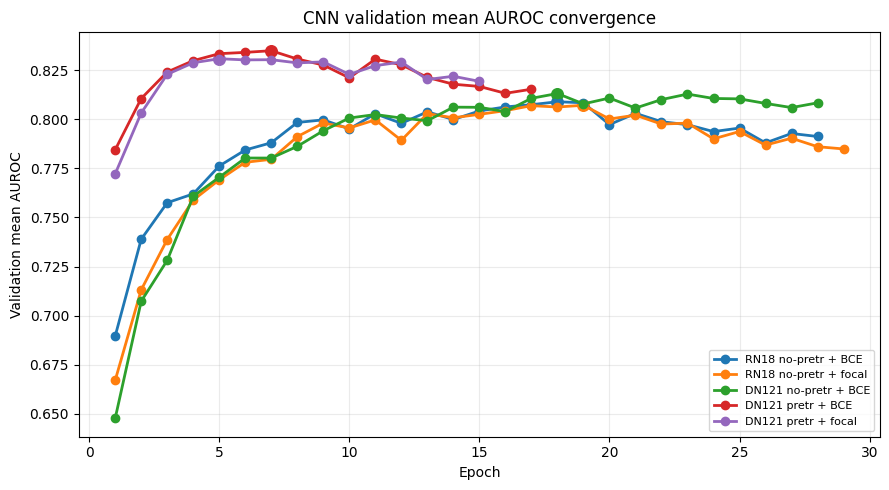

Saved: artifacts/metrics/report_figures/cnn_val_mean_auc_convergence.png


In [15]:
if len(viz_summary_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    for _, row in viz_summary_df.iterrows():
        history = histories.get(row["run_name"], pd.DataFrame())
        if history.empty or "val_mean_auc" not in history:
            continue
        ax.plot(history["epoch"], history["val_mean_auc"], marker="o", linewidth=2, label=row["short_label"])
        best_idx = history["val_mean_auc"].idxmax()
        ax.scatter(history.loc[best_idx, "epoch"], history.loc[best_idx, "val_mean_auc"], s=70)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation mean AUROC")
    ax.set_title("CNN validation mean AUROC convergence")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)
    fig.tight_layout()
    path = REPORT_FIG_DIR / "cnn_val_mean_auc_convergence.png"
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)


### 9.2 Training Loss, Validation Loss, and F1 Convergence

These plots help explain whether the model converges smoothly and whether F1 tracks the AUROC improvements.

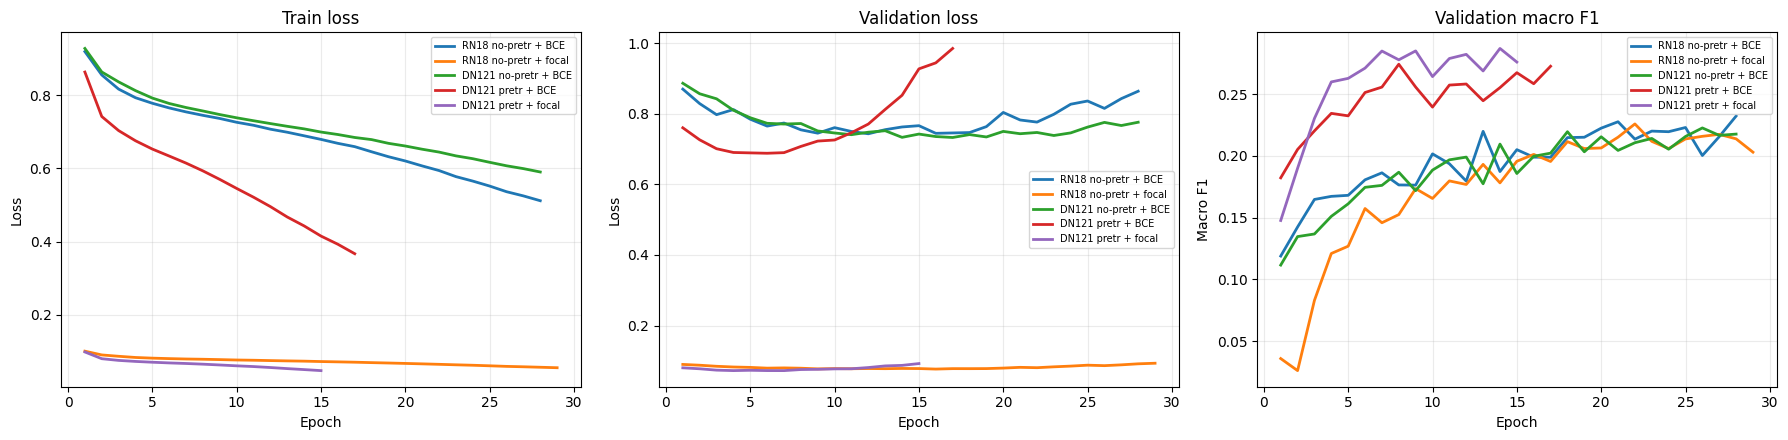

Saved: artifacts/metrics/report_figures/cnn_loss_f1_convergence_grid.png


In [16]:
if len(viz_summary_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    for _, row in viz_summary_df.iterrows():
        history = histories.get(row["run_name"], pd.DataFrame())
        if history.empty:
            continue
        label = row["short_label"]
        if "train_loss" in history:
            axes[0].plot(history["epoch"], history["train_loss"], linewidth=2, label=label)
        if "val_loss" in history:
            axes[1].plot(history["epoch"], history["val_loss"], linewidth=2, label=label)
        if "val_macro_f1" in history:
            axes[2].plot(history["epoch"], history["val_macro_f1"], linewidth=2, label=label)
    for ax, title, ylabel in zip(
        axes,
        ["Train loss", "Validation loss", "Validation macro F1"],
        ["Loss", "Loss", "Macro F1"],
    ):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=7)
    fig.tight_layout()
    path = REPORT_FIG_DIR / "cnn_loss_f1_convergence_grid.png"
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)


### 9.3 Final Test Metric Comparison

This is the main report table/figure for CNN model comparison.

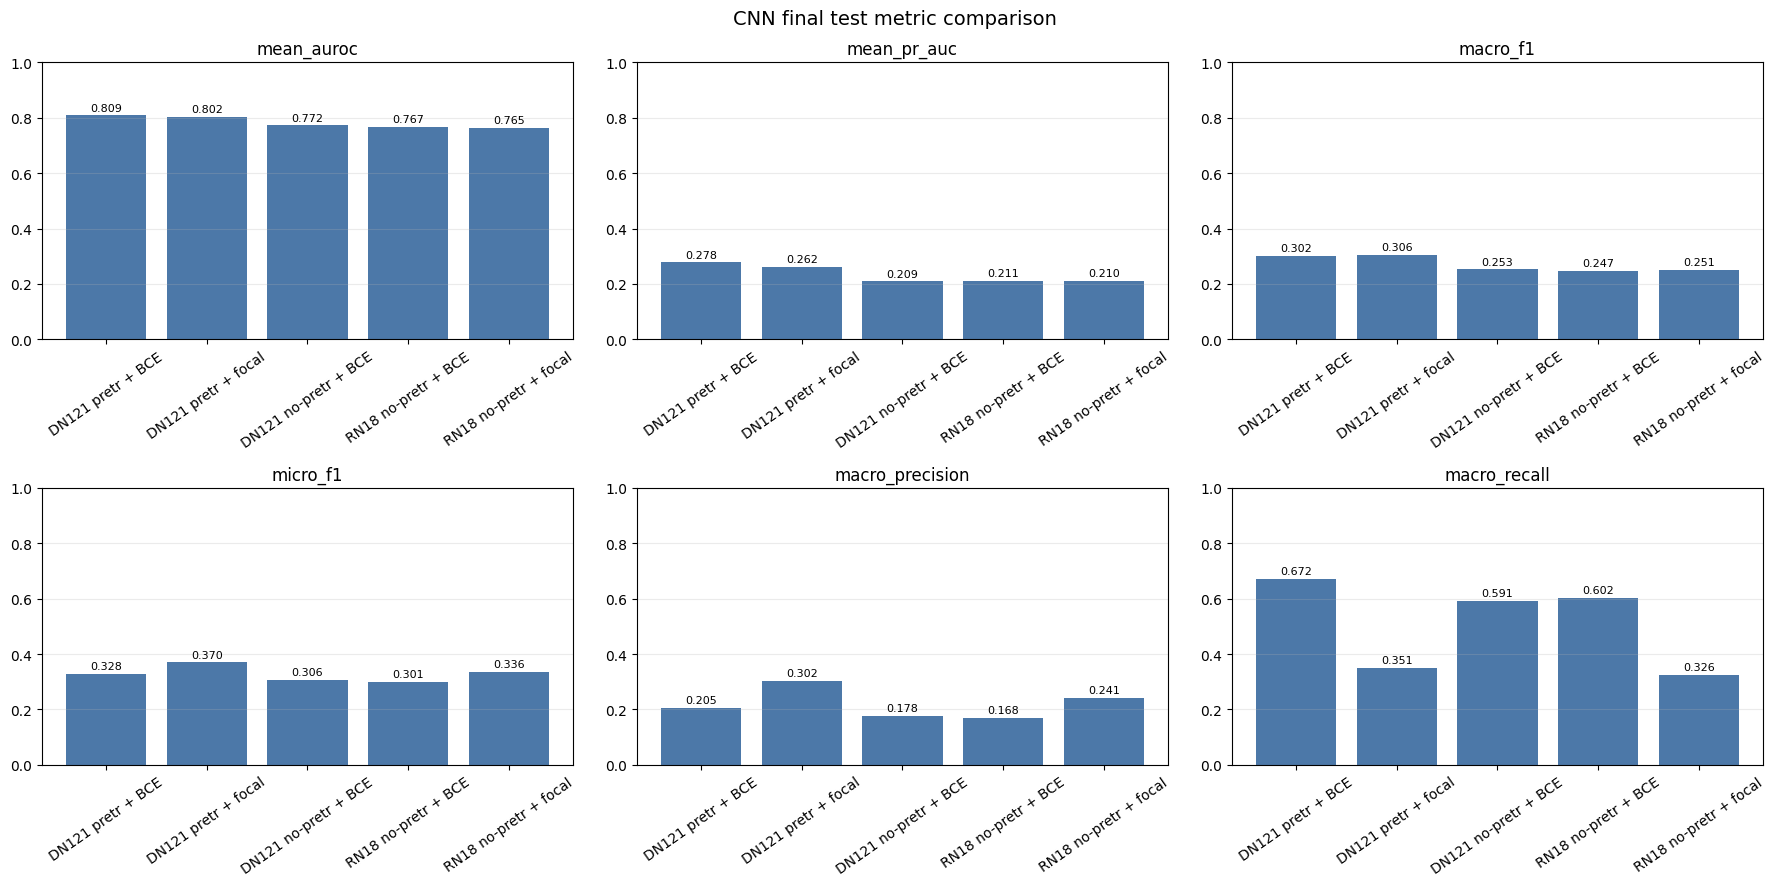

Saved: artifacts/metrics/report_figures/cnn_final_metric_comparison_grid.png


In [17]:
if len(viz_summary_df):
    plot_df = viz_summary_df.sort_values("mean_auroc", ascending=False).reset_index(drop=True)
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.ravel()
    for ax, metric in zip(axes, PLOT_METRICS):
        ax.bar(plot_df["short_label"], plot_df[metric], color="#4C78A8")
        ax.set_title(metric)
        ax.set_ylim(0, max(1.0, float(plot_df[metric].max()) * 1.15 if plot_df[metric].notna().any() else 1.0))
        ax.tick_params(axis="x", rotation=35)
        ax.grid(True, axis="y", alpha=0.25)
        for idx, value in enumerate(plot_df[metric]):
            if pd.notna(value):
                ax.text(idx, value + 0.01, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle("CNN final test metric comparison", fontsize=14)
    fig.tight_layout()
    path = REPORT_FIG_DIR / "cnn_final_metric_comparison_grid.png"
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)


### 9.4 Precision-Recall Tradeoff

This plot is useful for explaining why weighted BCE often gives high recall but lower precision, and how focal loss shifts that balance.

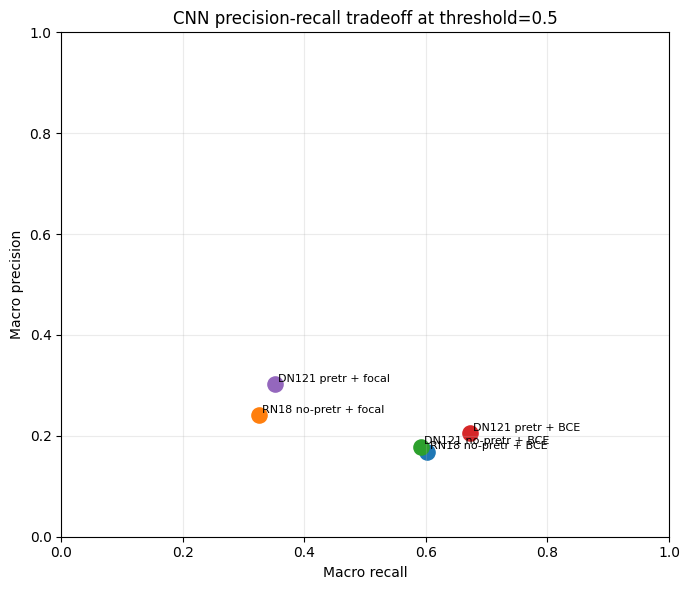

Saved: artifacts/metrics/report_figures/cnn_precision_recall_tradeoff.png


In [18]:
if len(viz_summary_df):
    fig, ax = plt.subplots(figsize=(7, 6))
    for _, row in viz_summary_df.iterrows():
        if pd.isna(row.get("macro_precision")) or pd.isna(row.get("macro_recall")):
            continue
        ax.scatter(row["macro_recall"], row["macro_precision"], s=120)
        ax.text(row["macro_recall"] + 0.005, row["macro_precision"] + 0.005, row["short_label"], fontsize=8)
    ax.set_xlabel("Macro recall")
    ax.set_ylabel("Macro precision")
    ax.set_title("CNN precision-recall tradeoff at threshold=0.5")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    path = REPORT_FIG_DIR / "cnn_precision_recall_tradeoff.png"
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)


### 9.5 Per-label AUROC and Average Precision Heatmaps

These heatmaps show which diseases each CNN setup handles well or poorly.

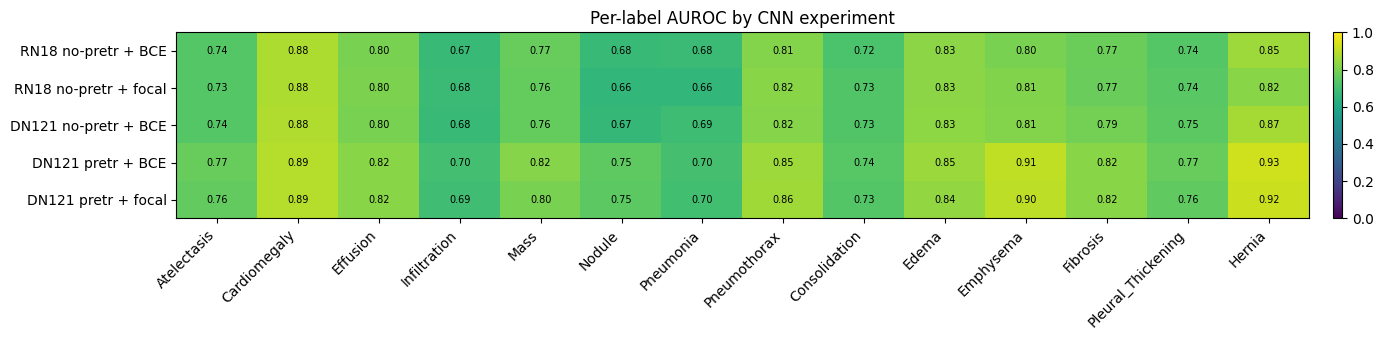

Saved: artifacts/metrics/report_figures/cnn_per_label_auroc_heatmap.png


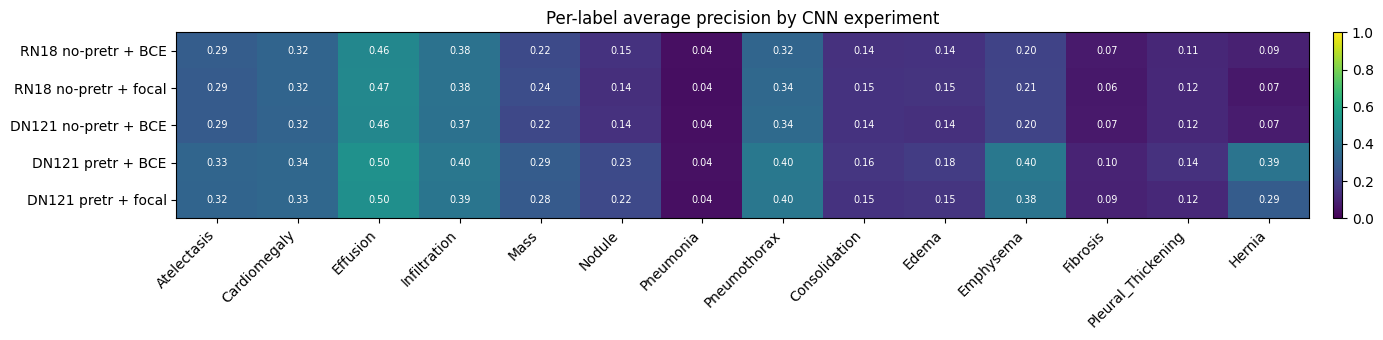

Saved: artifacts/metrics/report_figures/cnn_per_label_ap_heatmap.png


In [19]:
def build_per_label_matrix(per_class_tables, value_col):
    rows = []
    for exp in EXPERIMENTS:
        run_name = exp["run_name"]
        table = per_class_tables.get(run_name, pd.DataFrame())
        if table.empty or value_col not in table:
            continue
        row = table.set_index("label")[value_col].rename(_short_name(exp["label"]))
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows)


def plot_heatmap(matrix, title, path, vmin=0.0, vmax=1.0):
    if matrix.empty:
        print("No data for", title)
        return
    fig, ax = plt.subplots(figsize=(14, max(3.5, 0.45 * len(matrix))))
    im = ax.imshow(matrix.values, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(matrix.shape[1]), labels=matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(matrix.shape[0]), labels=matrix.index)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.values[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7, color="white" if value < 0.55 else "black")
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)

auroc_matrix = build_per_label_matrix(per_class_tables, "auroc")
ap_matrix = build_per_label_matrix(per_class_tables, "pr_auc")

plot_heatmap(auroc_matrix, "Per-label AUROC by CNN experiment", REPORT_FIG_DIR / "cnn_per_label_auroc_heatmap.png")
plot_heatmap(ap_matrix, "Per-label average precision by CNN experiment", REPORT_FIG_DIR / "cnn_per_label_ap_heatmap.png")


### 9.6 Training Budget: Time and GPU Memory

Use this figure to report training cost. The average GPU utilization depends on `nvidia-smi` availability and is sampled during progress logging.

In [ ]:
if len(viz_summary_df):
    budget_df = viz_summary_df.copy()
    budget_df["total_run_time_min"] = budget_df["total_run_time_sec"] / 60.0
    budget_df = budget_df.sort_values("mean_auroc", ascending=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
    axes[0].bar(budget_df["short_label"], budget_df["total_run_time_min"], color="#59A14F")
    axes[0].set_title("Total run time")
    axes[0].set_ylabel("Minutes")

    axes[1].bar(budget_df["short_label"], budget_df["peak_gpu_memory_allocated_mb"], color="#F28E2B")
    axes[1].set_title("Peak GPU allocated memory")
    axes[1].set_ylabel("MB")

    axes[2].bar(budget_df["short_label"], budget_df["avg_gpu_utilization_percent"], color="#E15759")
    axes[2].set_title("Average GPU utilization")
    axes[2].set_ylabel("%")
    axes[2].set_ylim(0, 100)

    for ax in axes:
        ax.tick_params(axis="x", rotation=35)
        ax.grid(True, axis="y", alpha=0.25)
    fig.suptitle("CNN training budget comparison", fontsize=14)
    fig.tight_layout()
    path = REPORT_FIG_DIR / "cnn_training_budget_comparison.png"
    fig.savefig(path, dpi=180)
    plt.show()
    print("Saved:", path)


### 9.7 Best Epoch and Early Stopping Summary

This helps document convergence and the selected checkpoint for each experiment.

In [ ]:
if len(viz_summary_df):
    stop_cols = [
        "label",
        "checkpoint_epoch",
        "checkpoint_val_mean_auc",
        "best_val_mean_auc_from_history",
        "mean_auroc",
        "mean_epoch_time_sec",
        "total_run_time_sec",
        "peak_gpu_memory_allocated_mb",
        "avg_gpu_memory_allocated_mb",
        "avg_gpu_utilization_percent",
    ]
    available_cols = [c for c in stop_cols if c in viz_summary_df.columns]
    display(viz_summary_df[available_cols].sort_values("checkpoint_val_mean_auc", ascending=False))
    out = REPORT_FIG_DIR / "cnn_early_stopping_budget_summary.csv"
    viz_summary_df[available_cols].to_csv(out, index=False)
    print("Saved:", out)
